# Benchmarking $k$-WL and a local-neighborhood variant

This notebook implements, for general `k`:

1. the standard **$k$-WL**, and  
2. the variant from the problem statement that only aggregates colors obtained by replacing coordinate $i$ with a **neighbor** of $v_i$.

It then benchmarks both algorithms on **Erdős–Rényi** graphs $G(n,p)$ for different values of `p`, and visualizes how computation time changes as graph density varies.

## Notes

- The implementation follows the hints in the sheet:
  - generate all $k$-tuples with `itertools.product`
  - encode the atomic type of a tuple
  - maintain colors in Python dictionaries
  - recolor using a canonical dictionary-based compression
- To make results reproducible, the benchmark uses fixed random seeds.
- The code is written to be clear and faithful to the definition, not maximally optimized.

In [1]:
import itertools
import math
import time
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

## Core implementation

I represent a $k$-tuple by a Python tuple like `(v1, ..., vk)`.

### Atomic type
For a tuple $\mathbf{v}=(v_1,\dots,v_k)$, the atomic type is encoded by the flattened $k\times k$ matrix with entries:

- `2` if `v_i == v_j`
- `1` if `(v_i, v_j)` is an edge
- `0` otherwise

This is the same representation suggested in the hint sheet.

In [12]:
def all_k_tuples(vertices, k):
    return list(itertools.product(vertices, repeat=k))


def atomic_type(G, tup):
    k = len(tup)
    enc = []
    for i in range(k):
        for j in range(k):
            if tup[i] == tup[j]:
                enc.append(2)
            elif G.has_edge(tup[i], tup[j]):
                enc.append(1)
            else:
                enc.append(0)
    return tuple(enc)


def initialize_colors(G, k):
    vertices = list(G.nodes())
    tuples_ = all_k_tuples(vertices, k)

    raw = {t: atomic_type(G, t) for t in tuples_}
    color_map = {}
    next_color = 0
    colors = {}
    for t in tuples_:
        sig = raw[t]
        if sig not in color_map:
            color_map[sig] = next_color
            next_color += 1
        colors[t] = color_map[sig]
    return tuples_, colors


def recolor_from_signatures(tuples_, signatures):
    color_map = {}
    next_color = 0
    new_colors = {}
    for t in tuples_:
        sig = signatures[t]
        if sig not in color_map:
            color_map[sig] = next_color
            next_color += 1
        new_colors[t] = color_map[sig]
    return new_colors


def color_histogram(colors):
    return tuple(sorted(Counter(colors.values()).items()))

## Standard $k$-WL

For each tuple $\mathbf{v}$ and each coordinate $i$, standard $k$-WL looks at all tuples obtained by replacing the $i$-th coordinate with **every** vertex in the graph.

In [13]:
def standard_kwl_step(G, tuples_, colors, k, vertices):
    signatures = {}
    for t in tuples_:
        agg_parts = []
        for i in range(k):
            neighbor_colors = []
            for w in vertices:
                s = list(t)
                s[i] = w
                neighbor_colors.append(colors[tuple(s)])
            agg_parts.append(tuple(sorted(neighbor_colors)))
        signatures[t] = (colors[t], tuple(agg_parts))
    return recolor_from_signatures(tuples_, signatures)


def run_standard_kwl(G, k, max_iter=25, return_trace=False):
    vertices = list(G.nodes())
    tuples_, colors = initialize_colors(G, k)
    trace = [color_histogram(colors)]

    for it in range(max_iter):
        new_colors = standard_kwl_step(G, tuples_, colors, k, vertices)
        trace.append(color_histogram(new_colors))
        if new_colors == colors:
            if return_trace:
                return new_colors, it + 1, trace
            return new_colors, it + 1
        colors = new_colors

    if return_trace:
        return colors, max_iter, trace
    return colors, max_iter

## Local-neighborhood variant from the problem

For each tuple $\mathbf{v}=(v_1,\dots,v_k)$ and coordinate $i$, the variant aggregates only the colors of tuples obtained by replacing $v_i$ with a vertex from **$N(v_i)$**.

So the standard $k$-WL aggregates over all `w in V(G)`, while this variant aggregates over only `w in N(v_i)`.

In [14]:
def local_variant_step(G, tuples_, colors, k, neighbor_dict):
    signatures = {}
    for t in tuples_:
        agg_parts = []
        for i in range(k):
            vi = t[i]
            neighbor_colors = []
            for w in neighbor_dict[vi]:
                s = list(t)
                s[i] = w
                neighbor_colors.append(colors[tuple(s)])
            agg_parts.append(tuple(sorted(neighbor_colors)))
        signatures[t] = (colors[t], tuple(agg_parts))
    return recolor_from_signatures(tuples_, signatures)


def run_local_kwl_variant(G, k, max_iter=25, return_trace=False):
    neighbor_dict = {v: list(G.neighbors(v)) for v in G.nodes()}
    tuples_, colors = initialize_colors(G, k)
    trace = [color_histogram(colors)]

    for it in range(max_iter):
        new_colors = local_variant_step(G, tuples_, colors, k, neighbor_dict)
        trace.append(color_histogram(new_colors))
        if new_colors == colors:
            if return_trace:
                return new_colors, it + 1, trace
            return new_colors, it + 1
        colors = new_colors

    if return_trace:
        return colors, max_iter, trace
    return colors, max_iter

## Small sanity check

This cell runs both algorithms on one small graph to verify that the functions work and return a stabilization iteration count.

In [5]:
G_test = nx.erdos_renyi_graph(n=8, p=0.35, seed=7)
k_test = 2

std_colors, std_iters = run_standard_kwl(G_test, k_test)
loc_colors, loc_iters = run_local_kwl_variant(G_test, k_test)

print("Standard k-WL stabilized in", std_iters, "iterations with", len(set(std_colors.values())), "final colors.")
print("Local variant stabilized in", loc_iters, "iterations with", len(set(loc_colors.values())), "final colors.")

Standard k-WL stabilized in 4 iterations with 64 final colors.
Local variant stabilized in 4 iterations with 64 final colors.


## Benchmark setup

I now benchmark both methods on Erdős–Rényi graphs `G(n,p)`.

### Benchmark design
For each value of `p`:
- generate several random graphs
- run both algorithms
- measure wall-clock time
- average the results

I can adjust:
- `N_VERTICES`
- `K`
- `P_VALUES`
- `NUM_TRIALS`

Increasing `k` or `n` makes the computation much heavier because there are `n^k` tuples.

In [6]:
def benchmark_kwl(
    n=18,
    k=2,
    p_values=None,
    num_trials=5,
    max_iter=20,
    base_seed=1234,
):
    if p_values is None:
        p_values = np.linspace(0.05, 0.95, 10)

    results = []
    for idx, p in enumerate(p_values):
        std_times = []
        loc_times = []
        edge_counts = []
        std_iters_list = []
        loc_iters_list = []

        for trial in range(num_trials):
            seed = base_seed + 1000 * idx + trial
            G = nx.erdos_renyi_graph(n=n, p=float(p), seed=seed)
            edge_counts.append(G.number_of_edges())

            t0 = time.perf_counter()
            _, std_iters = run_standard_kwl(G, k=k, max_iter=max_iter)
            t1 = time.perf_counter()

            _, loc_iters = run_local_kwl_variant(G, k=k, max_iter=max_iter)
            t2 = time.perf_counter()

            std_times.append(t1 - t0)
            loc_times.append(t2 - t1)
            std_iters_list.append(std_iters)
            loc_iters_list.append(loc_iters)

        results.append({
            "p": float(p),
            "avg_edges": float(np.mean(edge_counts)),
            "std_time_mean": float(np.mean(std_times)),
            "std_time_std": float(np.std(std_times)),
            "loc_time_mean": float(np.mean(loc_times)),
            "loc_time_std": float(np.std(loc_times)),
            "std_iters_mean": float(np.mean(std_iters_list)),
            "loc_iters_mean": float(np.mean(loc_iters_list)),
        })
    return results

In [7]:
# Main benchmark parameters
N_VERTICES = 18
K = 2
P_VALUES = np.linspace(0.05, 0.95, 10)
NUM_TRIALS = 5
MAX_ITER = 20

results = benchmark_kwl(
    n=N_VERTICES,
    k=K,
    p_values=P_VALUES,
    num_trials=NUM_TRIALS,
    max_iter=MAX_ITER,
    base_seed=42,
)

results

[{'p': 0.05,
  'avg_edges': 9.2,
  'std_time_mean': 0.024490290800076763,
  'std_time_std': 0.005735497456454182,
  'loc_time_mean': 0.005006449599886764,
  'loc_time_std': 0.001730206964328356,
  'std_iters_mean': 3.8,
  'loc_iters_mean': 3.8},
 {'p': 0.15,
  'avg_edges': 20.4,
  'std_time_mean': 0.025554896800076676,
  'std_time_std': 0.0020249871742581355,
  'loc_time_mean': 0.007009511599972029,
  'loc_time_std': 0.0013324173753426756,
  'std_iters_mean': 4.2,
  'loc_iters_mean': 4.2},
 {'p': 0.25,
  'avg_edges': 38.2,
  'std_time_mean': 0.017953907199989773,
  'std_time_std': 0.007684928926793576,
  'loc_time_mean': 0.006322964199944181,
  'loc_time_std': 0.002252864425356291,
  'std_iters_mean': 3.6,
  'loc_iters_mean': 3.6},
 {'p': 0.35,
  'avg_edges': 50.0,
  'std_time_mean': 0.010889870199980578,
  'std_time_std': 0.0014779718567292236,
  'loc_time_mean': 0.005423875200040129,
  'loc_time_std': 0.000733476760427718,
  'std_iters_mean': 3.4,
  'loc_iters_mean': 3.4},
 {'p': 0.4

## Convert results to arrays for plotting

In [8]:
p_vals = np.array([r["p"] for r in results])
avg_edges = np.array([r["avg_edges"] for r in results])

std_mean = np.array([r["std_time_mean"] for r in results])
std_std  = np.array([r["std_time_std"] for r in results])

loc_mean = np.array([r["loc_time_mean"] for r in results])
loc_std  = np.array([r["loc_time_std"] for r in results])

std_iters_mean = np.array([r["std_iters_mean"] for r in results])
loc_iters_mean = np.array([r["loc_iters_mean"] for r in results])

## Plot: runtime vs. edge probability $p$

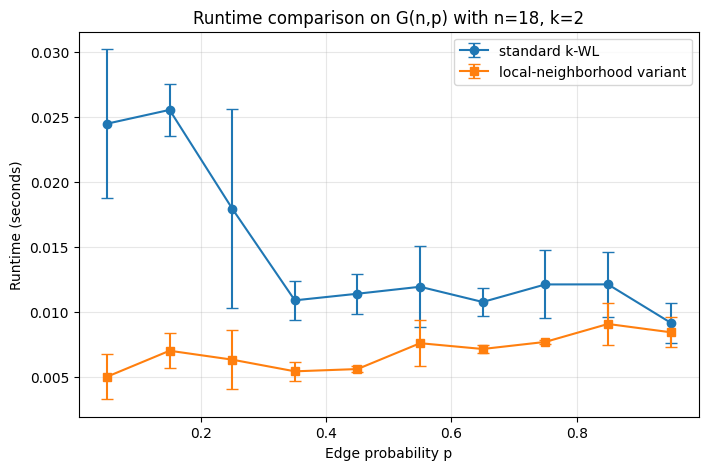

In [9]:
plt.figure(figsize=(8, 5))
plt.errorbar(p_vals, std_mean, yerr=std_std, marker="o", capsize=4, label="standard k-WL")
plt.errorbar(p_vals, loc_mean, yerr=loc_std, marker="s", capsize=4, label="local-neighborhood variant")
plt.xlabel("Edge probability p")
plt.ylabel("Runtime (seconds)")
plt.title(f"Runtime comparison on G(n,p) with n={N_VERTICES}, k={K}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Plot: average number of edges vs. $p$

This confirms that increasing `p` increases graph density as expected.

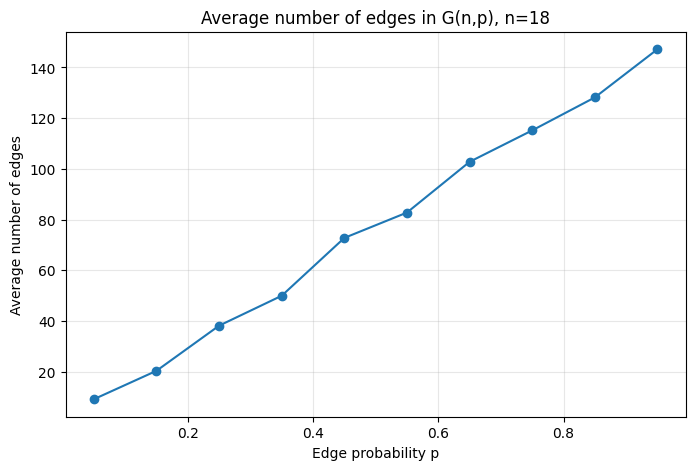

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(p_vals, avg_edges, marker="o")
plt.xlabel("Edge probability p")
plt.ylabel("Average number of edges")
plt.title(f"Average number of edges in G(n,p), n={N_VERTICES}")
plt.grid(True, alpha=0.3)
plt.show()

## Plot: average stabilization iterations

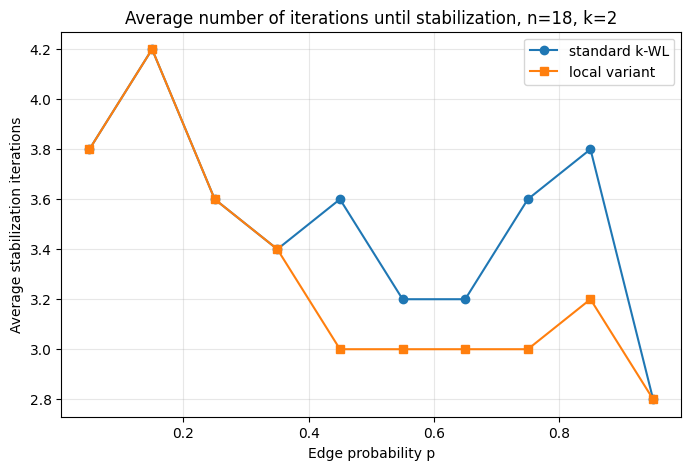

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(p_vals, std_iters_mean, marker="o", label="standard k-WL")
plt.plot(p_vals, loc_iters_mean, marker="s", label="local variant")
plt.xlabel("Edge probability p")
plt.ylabel("Average stabilization iterations")
plt.title(f"Average number of iterations until stabilization, n={N_VERTICES}, k={K}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Observation template

Typical behavior I should observe:

- The **standard $k$-WL** is usually **less sensitive to graph density** in its inner aggregation cost, because for each tuple and coordinate it always scans **all vertices**.
- The **local-neighborhood variant** is usually **more sensitive to `p`**, because for each tuple and coordinate it scans only the neighborhood `N(v_i)`, whose expected size is roughly `(n-1)p`.
- Therefore:
  - for **small `p`** (sparse graphs), the local variant is often **faster**
  - as **`p` increases**, the local variant becomes **slower**
  - when the graph becomes very dense, the local variant may approach the runtime of the standard $k$-WL

The exact curves can vary because:
- the number of refinement iterations until stabilization may also change with `p`
- Python dictionary and tuple-handling overhead is non-negligible
- random graph instances fluctuate across trials

## Final concise answer to the question

When varying `p` in Erdős–Rényi graphs:

- the runtime of **standard $k$-WL** tends to stay comparatively more stable with respect to `p`, because each update aggregates over all vertices
- the runtime of the **neighbor-only variant** tends to increase with `p`, because larger `p` means larger neighborhoods and therefore more colors to aggregate
- hence the neighbor-only variant is typically faster on **sparse graphs** and loses that advantage as the graph becomes **dense**

This is exactly what one would expect from the difference between aggregating over `V(G)` versus aggregating over `N(v_i)`.